# Import

In [1]:
import time
import re
import datetime
from datetime import timedelta
import transformers, datasets
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet, stopwords
from nltk.stem import WordNetLemmatizer

# nltk.download('popular')

lemmatizer = WordNetLemmatizer()
wordnet_map = {"N":wordnet.NOUN, "V":wordnet.VERB, "J":wordnet.ADJ, "R":wordnet.ADV}
datetime.datetime.now().strftime("%m-%d-%Y, %H:%M:%S")

'03-11-2023, 17:16:31'

# data

In [2]:
imdb_set = datasets.load_dataset('imdb')
# tomato_set = datasets.load_dataset('rotten_tomatoes')
print(imdb_set)
# print(tomato_set)

Found cached dataset imdb (/home/kd/.cache/huggingface/datasets/imdb/plain_text/1.0.0/d613c88cf8fa3bab83b4ded3713f1f74830d1100e171db75bbddb80b3345c9c0)


  0%|          | 0/3 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


# data sample

In [3]:
imdb_set['train'][0]

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

# prepare data

In [4]:
imdb_trn_df = pd.DataFrame(imdb_set['train'])
imdb_tst_df = pd.DataFrame(imdb_set['test'])

In [5]:
# clean & prepare data
def clean_sentences(line):
    
    # line=re.sub('<.*?>','',line) # removing html tags
    
    #removing contractions
    line=re.sub("isn't",'is not',line)
    line=re.sub("he's",'he is',line)
    line=re.sub("wasn't",'was not',line)
    line=re.sub("there's",'there is',line)
    line=re.sub("couldn't",'could not',line)
    line=re.sub("won't",'will not',line)
    line=re.sub("they're",'they are',line)
    line=re.sub("she's",'she is',line)
    line=re.sub("There's",'there is',line)
    line=re.sub("wouldn't",'would not',line)
    line=re.sub("haven't",'have not',line)
    line=re.sub("That's",'That is',line)
    line=re.sub("you've",'you have',line)
    line=re.sub("He's",'He is',line)
    line=re.sub("what's",'what is',line)
    line=re.sub("weren't",'were not',line)
    line=re.sub("we're",'we are',line)
    line=re.sub("hasn't",'has not',line)
    line=re.sub("you'd",'you would',line)
    line=re.sub("shouldn't",'should not',line)
    line=re.sub("let's",'let us',line)
    line=re.sub("they've",'they have',line)
    line=re.sub("You'll",'You will',line)
    line=re.sub("i'm",'i am',line)
    line=re.sub("we've",'we have',line)
    line=re.sub("it's",'it is',line)
    line=re.sub("don't",'do not',line)
    line=re.sub("that´s",'that is',line)
    line=re.sub("I´m",'I am',line)
    line=re.sub("it’s",'it is',line)
    line=re.sub("she´s",'she is',line)
    line=re.sub("he’s'",'he is',line)
    line=re.sub('I’m','I am',line)
    line=re.sub('I’d','I did',line)
    line=re.sub("he’s'",'he is',line)
    line=re.sub('there’s','there is',line)
    
    #special characters and emojis
    line=re.sub('\x91The','The',line)
    line=re.sub('\x97','',line)
    line=re.sub('\x84The','The',line)
    line=re.sub('\uf0b7','',line)
    line=re.sub('¡¨','',line)
    line=re.sub('\x95','',line)
    line=re.sub('\x8ei\x9eek','',line)
    line=re.sub('\xad','',line)
    line=re.sub('\x84bubble','bubble',line)
    
    # remove concated words
    line=re.sub('trivialBoring','trivial Boring',line)
    line=re.sub('Justforkix','Just for kix',line)
    line=re.sub('Nightbeast','Night beast',line)
    line=re.sub('DEATHTRAP','Death Trap',line)
    line=re.sub('CitizenX','Citizen X',line)
    line=re.sub('10Rated','10 Rated',line)
    line=re.sub('_The','_ The',line)
    line=re.sub('1Sound','1 Sound',line)
    line=re.sub('blahblahblahblahblahblahblahblahblahblahblahblahblahblahblahblahblahblah','blah blah',line)
    line=re.sub('ResidentHazard','Resident Hazard',line)
    line=re.sub('iameracing','i am racing',line)
    line=re.sub('BLACKSNAKE','Black Snake',line)
    line=re.sub('DEATHSTALKER','Death Stalker',line)
    line=re.sub('_is_','is',line)
    line=re.sub('10Fans','10 Fans',line)
    line=re.sub('Yellowcoat','Yellow coat',line)
    line=re.sub('Spiderbabe','Spider babe',line)
    line=re.sub('Frightworld','Fright world',line)

    return line


def strip_html(text):
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text()


def remove_stopwords(text):
    words = set(stopwords.words("english")) # conversion into set for fast searching !!!
    example_review = [word for word in text if word not in words]              
    return text


def lemmatize_words(text):
    text = strip_html(text)
    pos_tagged_text = nltk.pos_tag(text.split())
    return " ".join([lemmatizer.lemmatize(word, wordnet_map.get(pos[0], wordnet.NOUN)) for word, pos in pos_tagged_text])
    

def prepare_data(data, name):
    
    line = '='*60
    print(line)
    print(f'Handling data: {name}')
    print(line)
    print('descriptive stats:')
    print(data['text'].apply(lambda x: len(x)).describe())
    print(line)

    # check for HTML tags present in the text
    print('HTML tags found: ', data['text'].loc[data[data['text'].apply(lambda x: '<br' in x)].index].count())
    print(line)

    # remove HTML tags
    data['text'] = data['text'].apply(lambda x: strip_html(x))
    print('HTML tags found (after removing): ', data['text'].loc[data[data['text'].apply(lambda x: '<br' in x)].index].count())
    print(line)

    # remove stop words
    print('removing stopwords..')
    data['text'] = data['text'].apply(lambda x: remove_stopwords(x))
    print(line)

    # simplify contractions, special chars, emojis & concated words
    print('Cleanig further by replacing contractions, special chars, emojis & concated words..')
    data['text'] = data['text'].apply(lambda x: clean_sentences(x))
    print(line)

    # lower casing & lemmatize text
    print('Performed lemmatization in', end=' ')
    t0 = time.time()
    data['text'] = data['text'].apply(lambda x: lemmatize_words(x.lower()))
    print(str(timedelta(seconds=time.time()-t0)))

    return data

# combine ***IMDB*** & ***Rotten tomatoes*** dataset




In [6]:
train_df = prepare_data(imdb_trn_df, 'IMDB train')
test_df = prepare_data(imdb_tst_df, 'IMDB test')

Handling data: IMDB train
descriptive stats:
count    25000.00000
mean      1325.06964
std       1003.13367
min         52.00000
25%        702.00000
50%        979.00000
75%       1614.00000
max      13704.00000
Name: text, dtype: float64
HTML tags found:  14665


/home/kd/workspace/nltk-env/lib/python3.8/site-packages/bs4/__init__.py:435: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  warnings.warn(


HTML tags found (after removing):  0
removing stopwords..
Cleanig further by replacing contractions, special chars, emojis & concated words..
Performed lemmatization in 0:02:28.510293
Handling data: IMDB test
descriptive stats:
count    25000.00000
mean      1293.79240
std        975.90776
min         32.00000
25%        696.00000
50%        962.00000
75%       1572.00000
max      12988.00000
Name: text, dtype: float64
HTML tags found:  14535


/home/kd/workspace/nltk-env/lib/python3.8/site-packages/bs4/__init__.py:435: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  warnings.warn(


HTML tags found (after removing):  0
removing stopwords..
Cleanig further by replacing contractions, special chars, emojis & concated words..
Performed lemmatization in 0:02:25.340827


# train & Test dataset

In [7]:
train_df.loc[train_df['label'] == 1, 'label'] = 2
train_df.loc[train_df['label'] == 0, 'label'] = 1

train_df

,text,label
0,i rent i be curious-yellow from my video store...,1
1,"""i be curious: yellow"" be a risible and preten...",1
2,if only to avoid make this type of film in the...,1
3,this film be probably inspire by godard's masc...,1
4,"oh, brother...after hear about this ridiculous...",1
...,...,...
24995,a hit at the time but now well categorise a an...,2
24996,i love this movie like no other. another time ...,2
24997,this film and it be sequel barry mckenzie hold...,2
24998,'the adventure of barry mckenzie' start life a...,2


In [8]:
test_df.loc[test_df['label'] == 1, 'label'] = 2
test_df.loc[test_df['label'] == 0, 'label'] = 1

test_df

,text,label
0,i love sci-fi and be willing to put up with a ...,1
1,"worth the entertainment value of a rental, esp...",1
2,it a totally average film with a few semi-alri...,1
3,star rating: ***** saturday night **** friday ...,1
4,"first off let me say, if you have not enjoy a ...",1
...,...,...
24995,just get around to see monster man yesterday. ...,2
24996,i get this a part of a competition prize. i wa...,2
24997,i get monster man in a box set of three film w...,2
24998,"five minute in, i start to feel how naff this ...",2


# Vectorize - Train - Test (machine learning)

1.   CountVectorizer
2.   TfidfVectorizer

In [9]:
# vectorizer = CountVectorizer(max_features = 10000)
vectorizer = TfidfVectorizer(max_features = 10000)

# we convert our train & test data to feature vector matrix
train_x = vectorizer.fit_transform(train_df['text'])
test_x = vectorizer.transform(test_df['text'])

train_y = train_df['label']
test_y = test_df['label']

## Modeling

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, plot_confusion_matrix
from xgboost import XGBClassifier

## training & testing

              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88     12500
    Positive       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



/home/kd/workspace/nltk-env/lib/python3.8/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


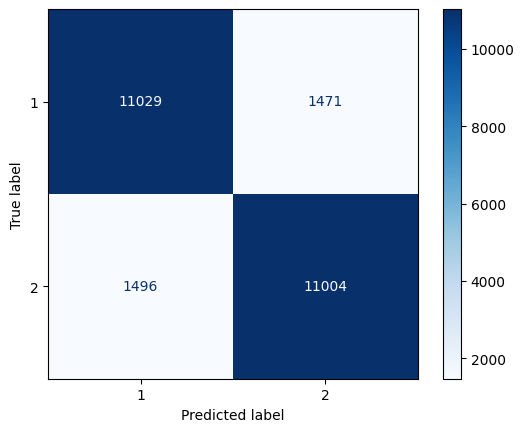

In [11]:
# Logistic Regression
# Negative       0.85      0.87      0.86     13033
# Positive       0.87      0.85      0.86     13033
# TfidfVectorizer
# Negative       0.87      0.88      0.88     13033
# Positive       0.88      0.87      0.88     13033
lr = LogisticRegression()
lr.fit(train_x, train_y)
pred_y=lr.predict(test_x)
print(classification_report(test_y, pred_y, target_names=['Negative', 'Positive']))
plot_confusion_matrix(lr, test_x, test_y,cmap = 'Blues')
plt.grid(False)


Iteration 1, loss = 0.51158476
Validation score: 0.883600
Iteration 2, loss = 0.26933997
Validation score: 0.895200
Iteration 3, loss = 0.19662358
Validation score: 0.892000
Iteration 4, loss = 0.15867679
Validation score: 0.894400
Iteration 5, loss = 0.13258198
Validation score: 0.890000
Iteration 6, loss = 0.11267124
Validation score: 0.885600
Iteration 7, loss = 0.09640563
Validation score: 0.882400
Iteration 8, loss = 0.08249347
Validation score: 0.882400
Iteration 9, loss = 0.07147365
Validation score: 0.879600
Iteration 10, loss = 0.06131657
Validation score: 0.878400
Iteration 11, loss = 0.05238274
Validation score: 0.875200
Iteration 12, loss = 0.04481245
Validation score: 0.875200
Iteration 13, loss = 0.03836077
Validation score: 0.871600
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
              precision    recall  f1-score   support

    Negative       0.86      0.91      0.88     12500
    Positive       0.90      0.85      0

/home/kd/workspace/nltk-env/lib/python3.8/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


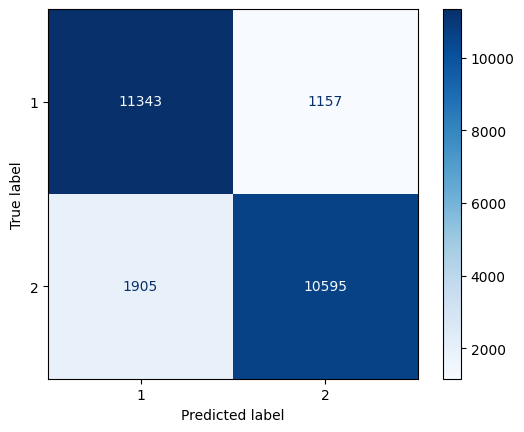

In [12]:

# MLP
# Negative       0.87      0.88      0.87     13033
# Positive       0.88      0.86      0.87     13033
# TfidfVectorizer
# Negative       0.87      0.88      0.88     13033
# Positive       0.88      0.87      0.87     13033
mlp = MLPClassifier(solver='adam', random_state=42, verbose=True, early_stopping=True)
mlp.fit(train_x, train_y)
pred_y=mlp.predict(test_x)
print(classification_report(test_y, pred_y, target_names=['Negative', 'Positive']))
plot_confusion_matrix(mlp, test_x, test_y,cmap = 'Blues')
plt.grid(False)


[LibLinear]....*
optimization finished, #iter = 47
Objective value = -5528.540702
nSV = 12953
              precision    recall  f1-score   support

    Negative       0.86      0.88      0.87     12500
    Positive       0.88      0.86      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



/home/kd/workspace/nltk-env/lib/python3.8/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


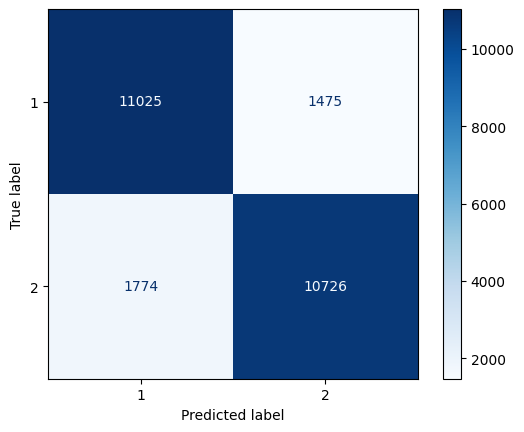

In [13]:

# svc 
# Negative       0.81      0.83      0.82     13033
# Positive       0.83      0.81      0.82     13033
# TfidfVectorizer
# Negative       0.85      0.87      0.86     13033
# Positive       0.87      0.85      0.86     13033
lr = LinearSVC(verbose=1)
lr.fit(train_x, train_y)
pred_y=lr.predict(test_x)
print(classification_report(test_y, pred_y, target_names=['Negative', 'Positive']))
plot_confusion_matrix(lr, test_x, test_y,cmap = 'Blues')
plt.grid(False)


              precision    recall  f1-score   support

    Negative       0.79      0.43      0.55     12500
    Positive       0.61      0.89      0.72     12500

    accuracy                           0.66     25000
   macro avg       0.70      0.66      0.64     25000
weighted avg       0.70      0.66      0.64     25000



/home/kd/workspace/nltk-env/lib/python3.8/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


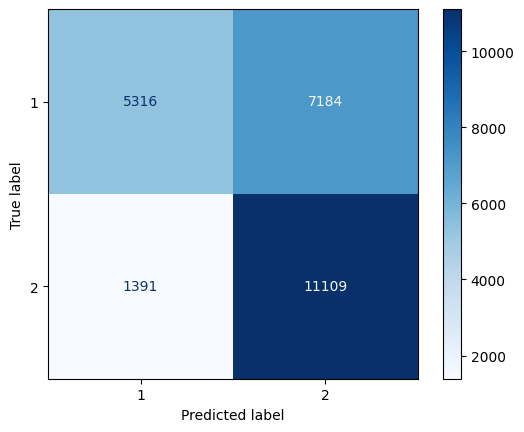

In [14]:

# AdaBoostClassifier
# Negative       0.77      0.44      0.56     13033
# Positive       0.61      0.87      0.72     13033
# TfidfVectorizer
# Negative       0.80      0.40      0.53     13033
# Positive       0.60      0.90      0.72     13033
clf = AdaBoostClassifier(n_estimators=100, random_state=42, learning_rate=0.001)
clf.fit(train_x, train_y)
pred_y=clf.predict(test_x)
print(classification_report(test_y, pred_y, target_names=['Negative', 'Positive']))
plot_confusion_matrix(clf, test_x, test_y,cmap = 'Blues')
plt.grid(False)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:  1.1min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.2s finished
/home/kd/workspace/nltk-env/lib/python3.8/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


              precision    recall  f1-score   support

    Negative       0.84      0.87      0.85     12500
    Positive       0.86      0.84      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.5s finished


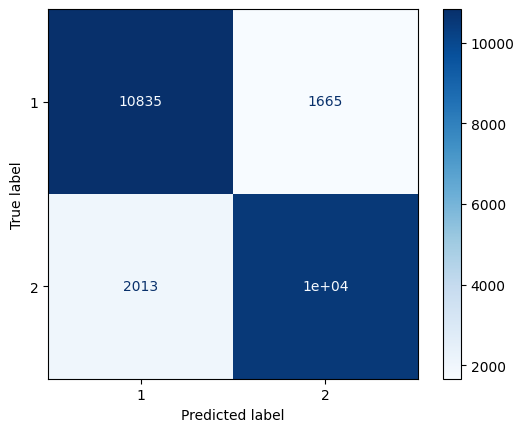

In [15]:

# ExtraTreesClassifier
# Negative       0.85      0.87      0.86     13033
# Positive       0.87      0.84      0.85     13033
# TfidfVectorizer
# Negative       0.84      0.86      0.85     13033
# Positive       0.86      0.83      0.84     13033
clf = ExtraTreesClassifier(n_estimators=100, random_state=42, verbose=1)
clf.fit(train_x, train_y)
pred_y=clf.predict(test_x)
print(classification_report(test_y, pred_y, target_names=['Negative', 'Positive']))
plot_confusion_matrix(clf, test_x, test_y,cmap = 'Blues')
plt.grid(False)


      Iter       Train Loss   Remaining Time 
         1           1.3859            1.38m
         2           1.3855            1.31m
         3           1.3851            1.28m
         4           1.3847            1.27m
         5           1.3843            1.25m
         6           1.3839            1.23m
         7           1.3835            1.22m
         8           1.3831            1.20m
         9           1.3827            1.19m
        10           1.3824            1.18m
        20           1.3785            1.04m
        30           1.3747           54.79s
        40           1.3710           46.58s
        50           1.3673           39.08s
        60           1.3638           31.44s
        70           1.3602           23.64s
        80           1.3568           15.77s
        90           1.3534            7.86s
       100           1.3501            0.00s
              precision    recall  f1-score   support

    Negative       0.80      0.49      0.61 

/home/kd/workspace/nltk-env/lib/python3.8/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


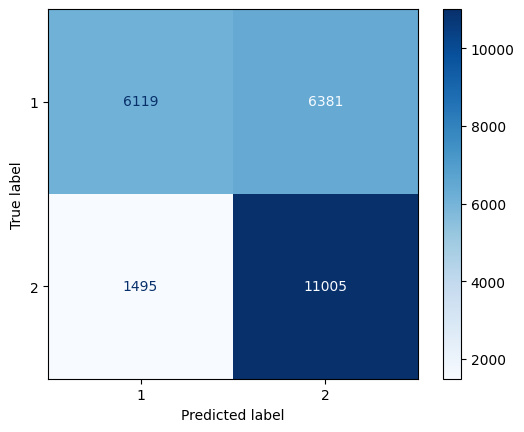

In [16]:

# GradientBoostingClassifier
# Negative       0.83      0.45      0.59     13033
# Positive       0.62      0.90      0.74     13033
# TfidfVectorizer
# Negative       0.80      0.47      0.60     13033
# Positive       0.63      0.88      0.73     13033
clf = GradientBoostingClassifier(n_estimators=100, random_state=42, verbose=1, learning_rate=0.001)
clf.fit(train_x, train_y)
pred_y=clf.predict(test_x)
print(classification_report(test_y, pred_y, target_names=['Negative', 'Positive']))
plot_confusion_matrix(clf, test_x, test_y,cmap = 'Blues')
plt.grid(False)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   46.4s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.0s finished
/home/kd/workspace/nltk-env/lib/python3.8/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


              precision    recall  f1-score   support

    Negative       0.83      0.85      0.84     12500
    Positive       0.85      0.82      0.83     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.0s finished


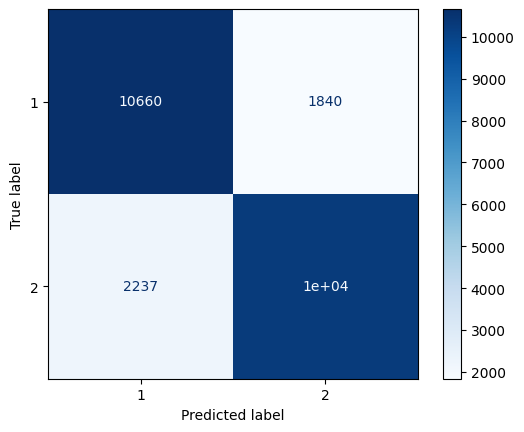

In [17]:

# RandomForestClassifier
# Negative       0.84      0.84      0.84     13033
# Positive       0.84      0.84      0.84     13033
# TfidfVectorizer
# Negative       0.82      0.85      0.84     13033
# Positive       0.85      0.81      0.83     13033
clf = RandomForestClassifier(n_estimators=100, random_state=42, verbose=1)
clf.fit(train_x, train_y)
pred_y=clf.predict(test_x)
print(classification_report(test_y, pred_y, target_names=['Negative', 'Positive']))
plot_confusion_matrix(clf, test_x, test_y,cmap = 'Blues')
plt.grid(False)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


building tree 1 of 100


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.5s remaining:    0.0s


building tree 2 of 100


[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.9s remaining:    0.0s


building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100

[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   43.7s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.0s finished
/home/kd/workspace/nltk-env/lib/python3.8/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remainin

              precision    recall  f1-score   support

    Negative       0.83      0.85      0.84     12500
    Positive       0.85      0.82      0.83     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.0s finished


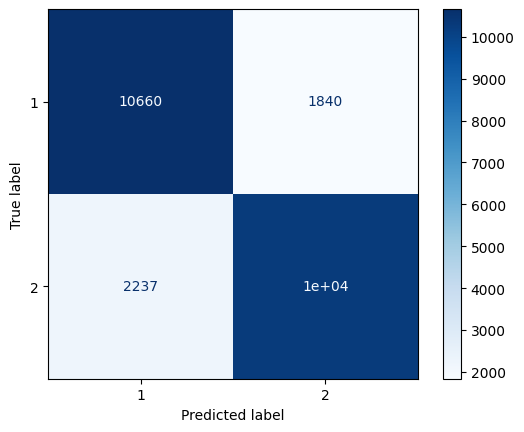

In [18]:

# XGBClassifier
# Negative       0.84      0.84      0.84     13033
# Positive       0.84      0.84      0.84     13033
# TfidfVectorizer
# Negative       0.82      0.85      0.84     13033
# Positive       0.85      0.81      0.83     13033
clf = RandomForestClassifier(n_estimators=100, random_state=42, verbose=3)
clf.fit(train_x, train_y)
pred_y=clf.predict(test_x)
print(classification_report(test_y, pred_y, target_names=['Negative', 'Positive']))
plot_confusion_matrix(clf, test_x, test_y,cmap = 'Blues')
plt.grid(False)


              precision    recall  f1-score   support

    Negative       0.66      0.81      0.73     12500
    Positive       0.76      0.59      0.66     12500

    accuracy                           0.70     25000
   macro avg       0.71      0.70      0.70     25000
weighted avg       0.71      0.70      0.70     25000



/home/kd/workspace/nltk-env/lib/python3.8/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


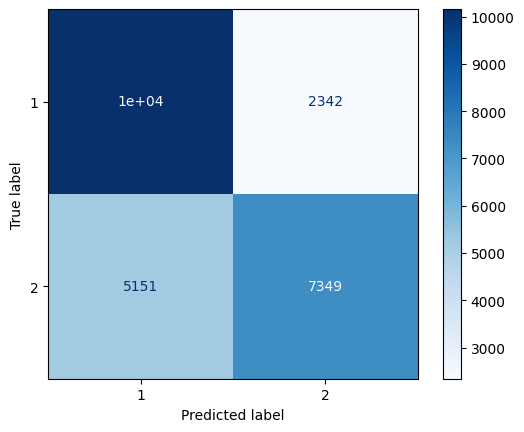

In [19]:

# GaussianNB
# Negative       0.61      0.84      0.71     13033
# Positive       0.75      0.47      0.58     13033
# TfidfVectorizer
# Negative       0.66      0.80      0.72     13033
# Positive       0.75      0.59      0.66     13033
clf = GaussianNB()
clf.fit(train_x.toarray(), train_y)
pred_y=clf.predict(test_x.toarray())
print(classification_report(test_y, pred_y, target_names=['Negative', 'Positive']))
plot_confusion_matrix(clf, test_x.toarray(), test_y,cmap = 'Blues')
plt.grid(False)


              precision    recall  f1-score   support

    Negative       0.80      0.87      0.84     12500
    Positive       0.86      0.79      0.82     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



/home/kd/workspace/nltk-env/lib/python3.8/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


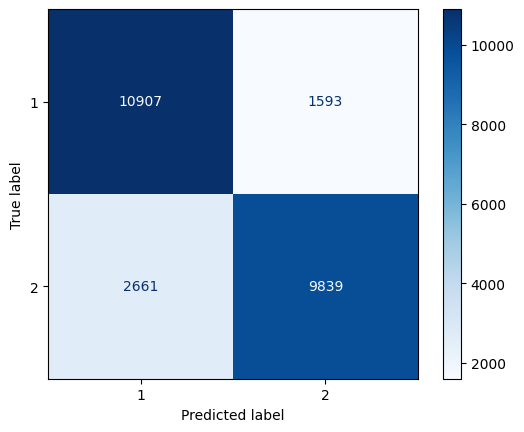

In [20]:

# MultinomialNB
# Negative       0.79      0.86      0.82     13033
# Positive       0.85      0.76      0.80     13033
# TfidfVectorizer
# Negative       0.80      0.87      0.83     13033
# Positive       0.86      0.78      0.82     13033
clf = MultinomialNB()
clf.fit(train_x.toarray(), train_y)
pred_y=clf.predict(test_x.toarray())
print(classification_report(test_y, pred_y, target_names=['Negative', 'Positive']))
plot_confusion_matrix(clf, test_x.toarray(), test_y,cmap = 'Blues')
plt.grid(False)